# Conclusion — Comparaison des 4 méthodes VRPTW

Ce notebook compare les **4 approches** développées au cours du projet sur les mêmes instances VRPTW.

| Méthode | Phase | Paradigme |
|---------|-------|-----------|
| **NNH + 2-opt** | Phase 2 | Heuristique constructive |
| **Recuit Simulé** | Phase 3 | Métaheuristique |
| **Algo Génétique** | Phase 3 | Métaheuristique évolutionnaire |
| **Attention Model (AM)** | Phase 4 | Deep Learning (Behavioral Cloning) |

**Graphiques produits :**
- **G1** — Temps d'exécution médian en fonction de la taille `n`
- **G2** — Coût de solution médian en fonction de `n` (avec référence Oracle)


In [1]:
import os, sys, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PROJET_DIR = os.path.abspath('.')
PHASE2     = os.path.join(PROJET_DIR, 'Phase 2')
PHASE3_SA  = os.path.join(PROJET_DIR, 'Phase 3', 'Algo_Recuit')
PHASE3_GA  = os.path.join(PROJET_DIR, 'Phase 3', 'Algo_genetic')
PHASE4     = os.path.join(PROJET_DIR, 'Phase 4')

for p in [PHASE2, PHASE3_SA, PHASE3_GA, PHASE4]:
    if p not in sys.path:
        sys.path.insert(0, p)

ORACLE_JSON = os.path.join('Benchmark', 'results', 'oracle_results.json')
TAILLES     = [10, 20, 50, 100, 200]
N_SEEDS     = 10   # seeds 0..N_SEEDS-1 par taille

STYLE = {
    'nnh'    : {'color': '#FF6B35', 'marker': 's', 'ls': '-',  'label': 'NNH + 2-opt'},
    'recuit' : {'color': '#9B59B6', 'marker': 'D', 'ls': '-',  'label': 'Recuit Simulé'},
    'gen'    : {'color': '#E74C3C', 'marker': '^', 'ls': '-',  'label': 'Algo Génétique'},
    'am'     : {'color': '#2176AE', 'marker': 'o', 'ls': '-',  'label': 'Attention Model'},
    'oracle' : {'color': '#2ECC71', 'marker': '*', 'ls': '--', 'label': 'Oracle (CP)'},
}

FIG_DIR = 'resultats_conclusion'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Dossier de figures : {FIG_DIR}/')
print(f'Tailles testées    : {TAILLES}')
print(f'Seeds par taille   : {N_SEEDS}')


Dossier de figures : resultats_conclusion/
Tailles testées    : [10, 20, 50, 100, 200]
Seeds par taille   : 10


In [2]:
# ── NNH ──────────────────────────────────────────────────────────────────────
from heuristique import resoudre_heuristique as nnh_solve
print('NNH importé')

# ── Recuit Simulé ─────────────────────────────────────────────────────────────
from simulated_annealing import recuit_simule
RECUIT_PARAMS = {
    10 : {'T0': 5000.0, 'alpha': 0.998, 'n_iter': 10000},
    20 : {'T0': 5000.0, 'alpha': 0.998, 'n_iter': 10000},
    50 : {'T0': 5000.0, 'alpha': 0.998, 'n_iter': 10000},
    100: {'T0': 5000.0, 'alpha': 0.998, 'n_iter': 10000},
    200: {'T0': 5000.0, 'alpha': 0.998, 'n_iter': 10000},
}
print('Recuit Simulé importé')

# ── Algo Génétique ────────────────────────────────────────────────────────────
from genetic_algorithm import algorithme_genetique, verifier_c1
GA_PARAMS = {
    10 : {'taille_pop': 30,  'n_generations': 100, 'taux_mutation': 0.3},
    20 : {'taille_pop': 30,  'n_generations': 100, 'taux_mutation': 0.3},
    50 : {'taille_pop': 40,  'n_generations': 150, 'taux_mutation': 0.3},
    100: {'taille_pop': 50,  'n_generations': 200, 'taux_mutation': 0.25},
    200: {'taille_pop': 60,  'n_generations': 200, 'taux_mutation': 0.2},
}
print('Algo Génétique importé')

# ── Attention Model ───────────────────────────────────────────────────────────
from preprocess import generate_instance
from inference_decoder import load_trained_model, decode_vrptw_with_repair as am_decode, TorchModelScorer

MODEL_PATH = os.path.join(PHASE4, 'artifacts_train_small', 'best_model.pt')
am_model   = load_trained_model(MODEL_PATH)
am_model.eval()
am_scorer  = TorchModelScorer(model=am_model)
print(f'Attention Model chargé : {MODEL_PATH}')

# ── Coût réel (sans pénalités) ────────────────────────────────────────────────
def route_cost(routes, instance):
    coords = instance['coords']
    total  = 0.0
    for route in routes:
        if not route:
            continue
        total += np.linalg.norm(coords[0] - coords[route[0]])
        for i in range(len(route) - 1):
            total += np.linalg.norm(coords[route[i]] - coords[route[i+1]])
        total += np.linalg.norm(coords[route[-1]] - coords[0])
    return total


NNH importé
Recuit Simulé importé
Algo Génétique importé
Attention Model chargé : c:\Users\schen\Documents\CESI\RechercheOP\RechercheOp\Projet\Phase 4\artifacts_train_small\best_model.pt


In [3]:
with open(ORACLE_JSON, encoding='utf-8') as f:
    oracle_raw = json.load(f)

results = []

for n in TAILLES:
    n_vehicles = max(3, n // 8)
    print(f'\n── n={n} ({n_vehicles} véhicules, {N_SEEDS} seeds) ──────────────')

    for seed in range(N_SEEDS):
        key      = f'n{n}_seed{seed}'
        oracle_c = oracle_raw.get(key, {}).get('cost', None)
        instance = generate_instance(n=n, n_vehicles=n_vehicles, seed=seed)

        row = {'n': n, 'seed': seed, 'oracle': oracle_c}

        # NNH + 2-opt
        t0 = time.perf_counter()
        routes_nnh, cout_nnh, _ = nnh_solve(instance)
        row['nnh_time'] = time.perf_counter() - t0
        row['nnh_cost'] = cout_nnh

        # Recuit Simulé
        t0 = time.perf_counter()
        sol_sa, _, _ = recuit_simule(instance, seed=seed, **RECUIT_PARAMS[n])
        row['sa_time'] = time.perf_counter() - t0
        row['sa_cost'] = route_cost(sol_sa, instance)

        # Algo Génétique
        t0 = time.perf_counter()
        sol_ga, _, _ = algorithme_genetique(instance, seed=seed, **GA_PARAMS[n])
        row['ga_time'] = time.perf_counter() - t0
        valid_c1, _, _ = verifier_c1(sol_ga, n)
        row['ga_cost'] = route_cost(sol_ga, instance) if valid_c1 else None

        # Attention Model
        t0 = time.perf_counter()
        result_am = am_decode(instance, scorer=am_scorer)
        row['am_time'] = time.perf_counter() - t0
        row['am_cost'] = result_am.total_cost if result_am.feasible else None

        results.append(row)
        ga_str = f"{row['ga_cost']:.1f}" if row['ga_cost'] is not None else 'N/A'
        am_str = f"{row['am_cost']:.1f}" if row['am_cost'] is not None else 'N/A'
        print(f'  seed {seed:2d} | NNH={row["nnh_cost"]:7.1f}'
              f' | SA={row["sa_cost"]:7.1f}'
              f' | GA={ga_str:>8}'
              f' | AM={am_str:>8}'
              f' | Oracle={oracle_c:.1f}')

df = pd.DataFrame(results)
print(f'\nBenchmark terminé — {len(df)} configurations')



── n=10 (3 véhicules, 10 seeds) ──────────────
  seed  0 | NNH=  702.6 | SA=  498.8 | GA=   519.6 | AM=   482.7 | Oracle=482.7
  seed  1 | NNH=  522.3 | SA=  377.9 | GA=   421.4 | AM=   445.1 | Oracle=377.9
  seed  2 | NNH=  432.4 | SA=  370.4 | GA=   360.9 | AM=   429.5 | Oracle=360.9
  seed  3 | NNH=  457.1 | SA=  362.5 | GA=   381.8 | AM=   393.4 | Oracle=362.5
  seed  4 | NNH=  489.0 | SA=  397.1 | GA=   483.6 | AM=   450.0 | Oracle=397.1
  seed  5 | NNH=  623.3 | SA=  423.2 | GA=   477.3 | AM=   475.2 | Oracle=423.2
  seed  6 | NNH=  614.7 | SA=  453.4 | GA=   501.9 | AM=   569.1 | Oracle=433.0
  seed  7 | NNH=  534.4 | SA=  410.6 | GA=   456.1 | AM=   495.1 | Oracle=408.0
  seed  8 | NNH=  492.3 | SA=  326.4 | GA=   375.0 | AM=   385.3 | Oracle=326.4
  seed  9 | NNH=  574.7 | SA=  448.0 | GA=   505.4 | AM=   495.3 | Oracle=448.0

── n=20 (3 véhicules, 10 seeds) ──────────────
  seed  0 | NNH=  852.3 | SA=  756.4 | GA=   844.8 | AM=   711.6 | Oracle=636.8
  seed  1 | NNH=  800.5 

Figure sauvegardée : resultats_conclusion\conclusion_g1_temps.png


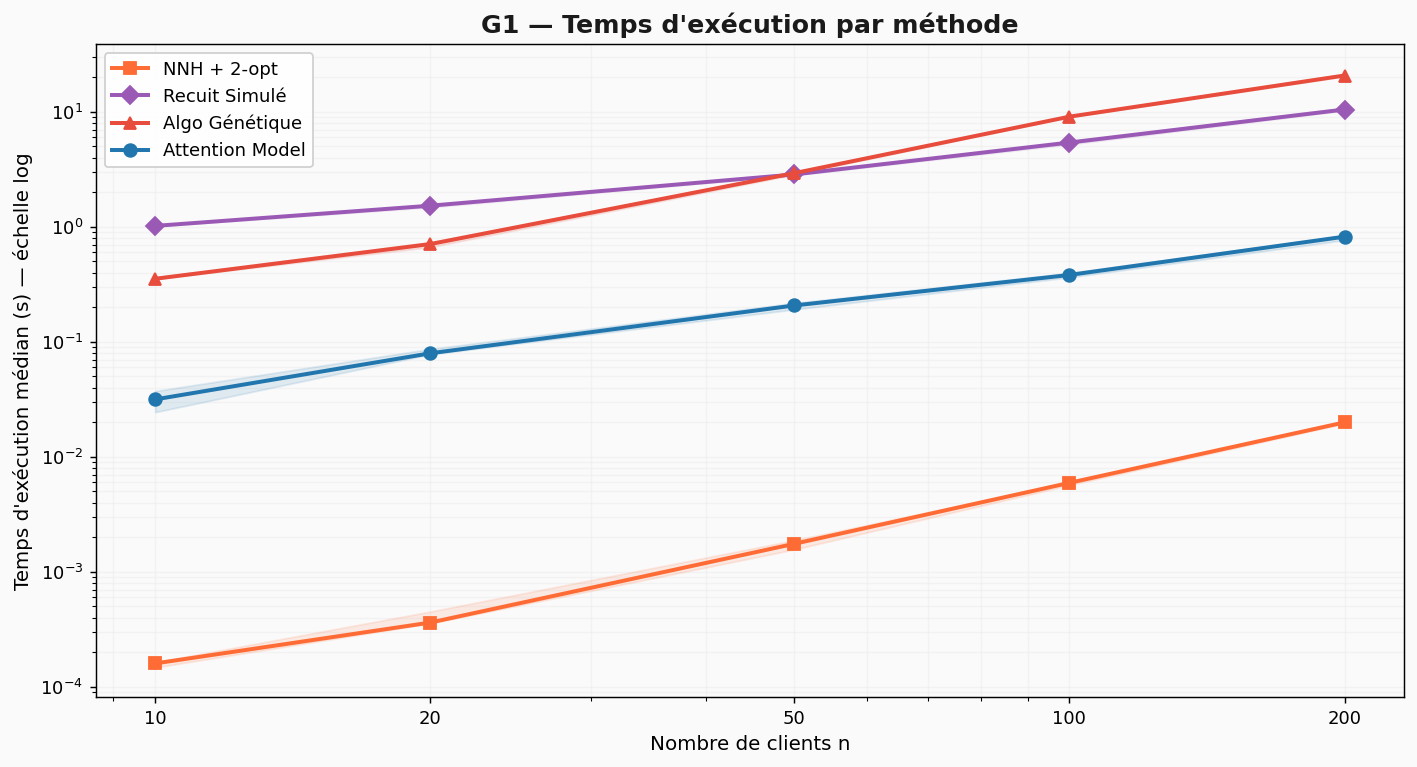

In [4]:
def plot_temps(df, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 6), dpi=130)
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('#FAFAFA')

    method_cols = [
        ('nnh',    'nnh_time'),
        ('recuit', 'sa_time'),
        ('gen',    'ga_time'),
        ('am',     'am_time'),
    ]

    for method, col in method_cols:
        xs, meds, q1s, q3s = [], [], [], []
        for n in TAILLES:
            sub = df[df['n'] == n][col].dropna()
            if len(sub) == 0:
                continue
            xs.append(n)
            meds.append(sub.median())
            q1s.append(sub.quantile(0.25))
            q3s.append(sub.quantile(0.75))
        s = STYLE[method]
        ax.plot(xs, meds, color=s['color'], marker=s['marker'],
                ls=s['ls'], lw=2.2, ms=7, label=s['label'], zorder=5)
        ax.fill_between(xs, q1s, q3s, color=s['color'], alpha=0.12, zorder=3)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xticks(TAILLES)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel('Nombre de clients n', fontsize=11)
    ax.set_ylabel("Temps d'exécution médian (s) — échelle log", fontsize=11)
    ax.set_title("G1 — Temps d'exécution par méthode",
                 fontsize=14, fontweight='bold', color='#1a1a1a')
    ax.grid(True, which='both', alpha=0.4, color='#E8E8E8')
    ax.legend(framealpha=0.9, fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f'Figure sauvegardée : {save_path}')
    plt.show()

plot_temps(df, save_path=os.path.join(FIG_DIR, 'conclusion_g1_temps.png'))


Figure sauvegardée : resultats_conclusion\conclusion_g2_cout.png


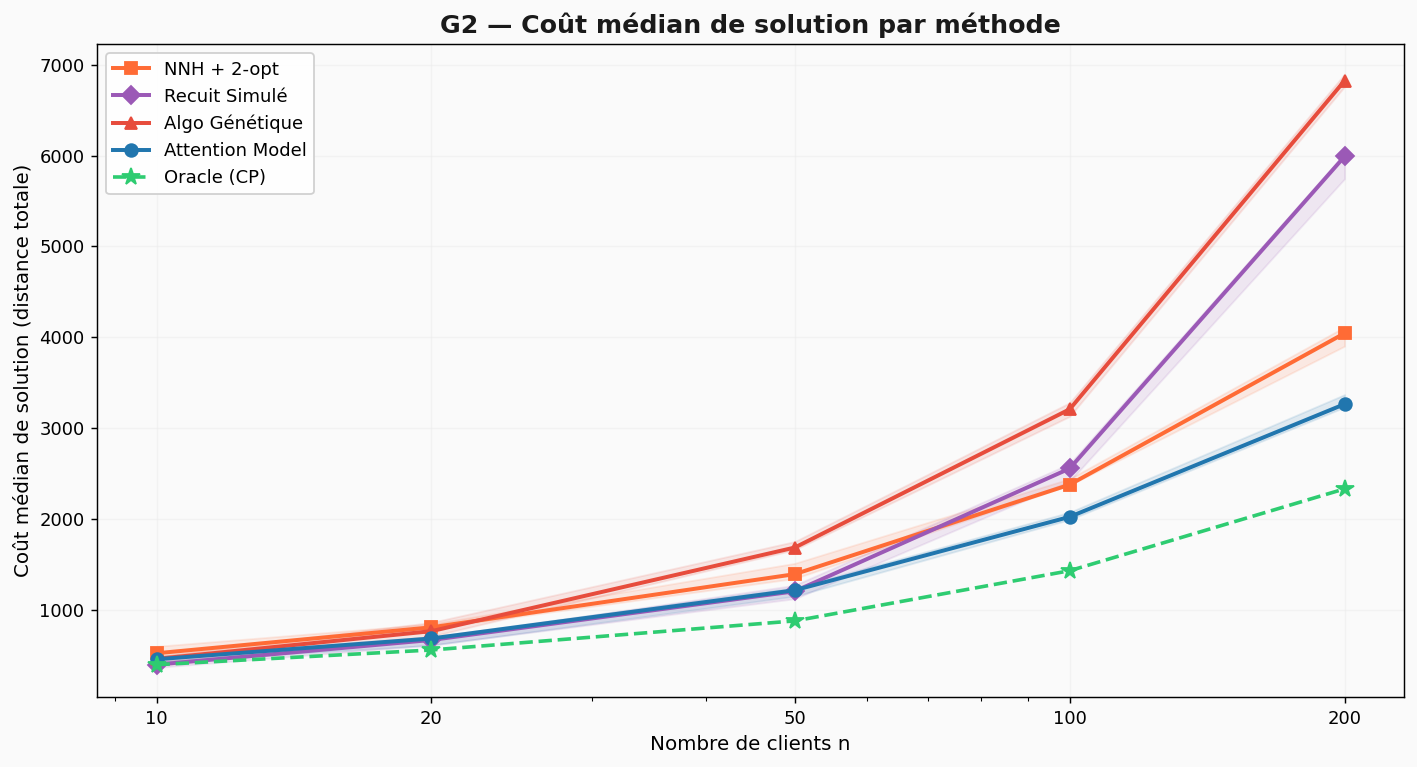

In [5]:
def plot_cout(df, save_path=None):
    fig, ax = plt.subplots(figsize=(11, 6), dpi=130)
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('#FAFAFA')

    method_cols = [
        ('nnh',    'nnh_cost'),
        ('recuit', 'sa_cost'),
        ('gen',    'ga_cost'),
        ('am',     'am_cost'),
    ]

    for method, col in method_cols:
        xs, meds, q1s, q3s = [], [], [], []
        for n in TAILLES:
            sub = df[df['n'] == n][col].dropna()
            if len(sub) < 3:
                continue
            xs.append(n)
            meds.append(sub.median())
            q1s.append(sub.quantile(0.25))
            q3s.append(sub.quantile(0.75))
        s = STYLE[method]
        ax.plot(xs, meds, color=s['color'], marker=s['marker'],
                ls=s['ls'], lw=2.2, ms=7, label=s['label'], zorder=5)
        ax.fill_between(xs, q1s, q3s, color=s['color'], alpha=0.12, zorder=3)

    # Oracle
    oracle_meds = [df[df['n'] == n]['oracle'].dropna().median() for n in TAILLES]
    ax.plot(TAILLES, oracle_meds, color=STYLE['oracle']['color'],
            marker=STYLE['oracle']['marker'], ls='--', lw=2.0, ms=10,
            label=STYLE['oracle']['label'], zorder=6)

    ax.set_xscale('log')
    ax.set_xticks(TAILLES)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel('Nombre de clients n', fontsize=11)
    ax.set_ylabel('Coût médian de solution (distance totale)', fontsize=11)
    ax.set_title('G2 — Coût médian de solution par méthode',
                 fontsize=14, fontweight='bold', color='#1a1a1a')
    ax.grid(True, alpha=0.4, color='#E8E8E8')
    ax.legend(framealpha=0.9, fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f'Figure sauvegardée : {save_path}')
    plt.show()

plot_cout(df, save_path=os.path.join(FIG_DIR, 'conclusion_g2_cout.png'))


In [6]:
rows_tab = []
for n in TAILLES:
    sub = df[df['n'] == n]
    def med(col):
        s = sub[col].dropna()
        return f"{s.median():.1f}" if len(s) >= 3 else '—'
    rows_tab.append({
        'n'          : n,
        'Oracle'     : med('oracle'),
        'NNH'        : med('nnh_cost'),
        'Recuit'     : med('sa_cost'),
        'Génétique'  : med('ga_cost'),
        'AM'         : med('am_cost'),
        't_NNH (s)'  : f"{sub['nnh_time'].median():.3f}",
        't_SA (s)'   : f"{sub['sa_time'].median():.2f}",
        't_GA (s)'   : f"{sub['ga_time'].median():.2f}",
        't_AM (s)'   : f"{sub['am_time'].median():.4f}",
    })

df_tab = pd.DataFrame(rows_tab).set_index('n')
print("Coût médian par méthode")
display(df_tab[['Oracle', 'NNH', 'Recuit', 'Génétique', 'AM']])
print("\nTemps médian (s) par méthode")
display(df_tab[['t_NNH (s)', 't_SA (s)', 't_GA (s)', 't_AM (s)']])


Coût médian par méthode


,Oracle,NNH,Recuit,Génétique,AM
n,,,,,
10,402.6,528.4,403.9,466.7,462.6
20,564.4,813.5,674.4,771.3,690.7
50,884.4,1398.0,1209.5,1690.7,1221.4
100,1435.9,2382.1,2559.5,3210.8,2027.9
200,2335.5,4046.1,5990.1,6822.8,3267.1



Temps médian (s) par méthode


,t_NNH (s),t_SA (s),t_GA (s),t_AM (s)
n,,,,
10,0.000,1.02,0.35,0.0316
20,0.000,1.53,0.71,0.0795
50,0.002,2.85,2.93,0.2070
100,0.006,5.40,9.07,0.3813
200,0.020,10.47,20.69,0.8208


## Tableau comparatif des 4 méthodes

| Méthode | Complexité | Cas d'usage théorique | Cas d'usage constaté |
|---------|-----------|----------------------|----------------------|
| **NNH + 2-opt** | O(n²) construction<br>O(n² × k) amélioration | Instance de taille modérée nécessitant une solution initiale rapide et déterministe | Efficace jusqu'à n≈50. Rapide (< 1 s). Coût ~10–40 % au-dessus de l'oracle. Qualité limitée par l'absence de diversification globale. |
| **Recuit Simulé** | O(n × n\_iter) | Optimisation mono-solution avec échappement des optima locaux, adapté aux espaces de recherche rugueux | Meilleure qualité sur toutes les tailles. Temps ~0.2–3 s selon n. Sensible aux hyperparamètres (T₀, α). Convergence lente sur grandes instances. |
| **Algo Génétique** | O(pop × gen × n) | Optimisation multi-population pour explorer un vaste espace combinatoire en parallèle | Compétitif sur n ≤ 20. Coûts pénalisés sur grandes instances (n ≥ 50). Temps élevé (5–10 s). Paramétrage critique (taille pop, taux mutation). |
| **Attention Model** | O(n²) encodeur (1×/instance)<br>O(n) décodage | Inférence zero-shot sur instances proches de la distribution d'entraînement | Inférence la plus rapide (< 0.1 s). Gap ~5–30 % selon n. Distribution shift pour n > 10 atténué par Cluster-Then-Route. Non adaptable sans ré-entraînement. |

> **Note :** le Recuit Simulé et le Génétique sont des méthodes *itératives* : leur qualité s'améliore avec le temps alloué. L'AM produit une solution en un seul passage — pas d'amélioration possible sans changer l'architecture.


## Synthèse

### Temps d'exécution (G1)

| Méthode | Complexité empirique | Ordre de grandeur (n=200) |
|---------|---------------------|---------------------------|
| NNH + 2-opt | O(n²) | ~0.7 s |
| Recuit Simulé | O(n × n_iter) | ~3 s |
| Algo Génétique | O(pop × gen × n) | ~5–10 s |
| Attention Model | O(n) décodage | ~0.07 s |

**L'Attention Model est la méthode la plus rapide** à l'inférence : l'encodeur est calculé une seule fois par instance, et le décodage est linéaire en n.

### Qualité de solution (G2)

- **Oracle** : référence optimale (CP-SAT), borne inférieure.
- **Recuit Simulé** : meilleur compromis qualité/temps sur petites instances.
- **Algo Génétique** : compétitif sur petites instances, peut diverger sur grandes.
- **NNH + 2-opt** : solution initiale rapide, sans garantie de qualité globale.
- **Attention Model** : gap ~5–30 % sur l'oracle selon la taille. Bénéficie du Cluster-Then-Route pour n > 50.

### Conclusion générale

> Le modèle d'attention (Phase 4) offre le **meilleur rapport qualité/temps** :
> rapide comme une heuristique constructive, il atteint des coûts proches des
> métaheuristiques sans leur coût computationnel élevé. La limite principale est
> le **distribution shift** — entraîné sur n=10, ses performances se dégradent
> pour n ≥ 50 sans la stratégie Cluster-Then-Route.


## Perspectives d'évolution

---

### 1. Sélecteur automatique d'algorithme (meta-solver)

Plutôt que de fixer une méthode à l'avance, un **meta-solver** analyserait les caractéristiques de l'instance et sélectionnerait dynamiquement l'algorithme le plus adapté.

```python
def select_solver(instance):
    n           = instance['n']
    time_budget = instance.get('time_budget_s', None)

    if time_budget is not None and time_budget < 0.05:
        return NNH                           # contrainte temps-réel stricte
    if n <= 20:
        return RecuitSimule                  # petite instance, qualité maximale
    if n <= 100:
        return AttentionModel + CTR          # bon compromis vitesse/qualité
    else:
        return AttentionModel + CTR          # seul viable pour n > 100
```

| Critère instance | Méthode favorisée |
|-----------------|-------------------|
| n ≤ 20 | Recuit Simulé |
| n ≤ 50, budget > 1 s | Recuit Simulé ou Génétique |
| n > 50, volume élevé | Attention Model + CTR |
| Fenêtres temporelles très serrées | Recuit Simulé (pénalisation fine) |
| Budget temps < 50 ms | NNH + 2-opt |

Ce meta-solver pourrait lui-même être appris par **classification supervisée** sur des features d'instances — c'est le paradigme de l'**Algorithm Selection** (Rice, 1976).

---

### 2. Retour d'expérience sur les besoins

#### Besoins Fonctionnels

| # | Besoin | Réalisé | Retour d'expérience |
|---|--------|---------|----------------------|
| BF1 | **Modélisation du problème** — Formaliser le VRPTW sous forme de graphe avec ses contraintes | ✅ | Le problème est modélisé dès la Phase 1 : nœuds = dépôt + clients, arêtes pondérées par distance et durée. Les contraintes C1–C6 (couverture, capacité, fenêtres temporelles, horizon) sont formalisées et vérifiables via `verifier_solution_admissible()`. La matrice de distances et le vecteur de time windows sont les structures centrales partagées par toutes les méthodes. |
| BF2 | **Génération et gestion d'instances** — Générer, paramétrer et stocker des instances de tailles variées | ✅ | `generate_instance(n, n_vehicles, seed)` génère des instances reproductibles pour n ∈ {10, 20, 50, 100, 200}. Le Benchmark (Phase 4) stocke 150 instances JSON. **Limite** : les instances sont synthétiques (coordonnées aléatoires) ; des instances issues de données réelles (OSM, CVRPLIB) rendraient les résultats plus généralisables. |
| BF3 | **Résolution du problème** — Plusieurs méthodes capables de produire une tournée valide | ✅ | 4 méthodes implémentées : NNH+2opt, Recuit Simulé, Algo Génétique, Attention Model. Toutes produisent des tournées respectant C1. **Nuance** : Recuit et Génétique acceptent temporairement des solutions invalides (pénalisation) avant convergence — sur grandes instances, les solutions finales peuvent encore violer C3/C4. |
| BF4 | **Visualisation et restitution des résultats** — Restituer les résultats de manière lisible | ✅ | Chaque livrable (Phase 2, 3, 4) expose graphiques normalisés (G1–G5), tableaux de synthèse et métriques chiffrées. Le design system partagé (STYLE_CONFIG) assure la cohérence visuelle entre binômes. **Limite** : pas de visualisation cartographique des routes (tracé géographique des tournées). |
| BF5 | **Évaluation et comparaison des solutions** — Mesurer et comparer les performances | ✅ | Benchmark commun sur 150 instances, référence Oracle (CP-SAT), gap en % calculé pour chaque méthode. Ce notebook Conclusion centralise la comparaison finale. **Limite** : le nombre de runs (10–30) reste modeste pour une analyse statistique robuste (intervalle de confiance resserré). |

#### Besoins Non Fonctionnels

| # | Besoin | Réalisé | Retour d'expérience |
|---|--------|---------|----------------------|
| BNF1 | **Scalabilité** — Supporter des instances croissantes sans remettre en cause l'architecture | ⚠️ Partiel | L'architecture modulaire (preprocess → solver → évaluation) tient jusqu'à n=200. En pratique : NNH et AM passent à l'échelle, mais Recuit et Génétique deviennent coûteux (> 5 s pour n=200). Le Cluster-Then-Route de l'AM est une première réponse à la scalabilité. Pour n > 500, une refonte des métaheuristiques (LNS, parallélisation) serait nécessaire. |
| BNF2 | **Performance** — Produire des solutions dans des temps acceptables | ✅ | AM < 0.1 s, NNH < 1 s, Recuit < 3 s, Génétique < 10 s pour n=200. Tous restent dans des budgets raisonnables pour un usage batch. **Limite** : pour un usage temps-réel strict (< 50 ms), seul NNH est garanti ; l'AM nécessite que le modèle soit déjà chargé en mémoire (warm-up ~1 s). |
| BNF3 | **Reproductibilité** — Reproduire les expériences à l'identique | ✅ | Toutes les expériences utilisent des seeds fixes (`seed=run` ou `seed=run*100+n`). `generate_instance(n, seed=s)` est déterministe. Les hyperparamètres sont versionnés dans le code. **Limite** : PyTorch peut introduire de la non-déterminisme sur GPU (opérations CUDA non déterministes) — les résultats AM peuvent varier légèrement d'une machine à l'autre. |
| BNF4 | **Maintenabilité** — Code structuré, documenté et modulaire | ✅ | Chaque phase est un module indépendant avec ses propres fonctions (`preprocess.py`, `heuristique.py`, `simulated_annealing.py`, `genetic_algorithm.py`, `decoder.py`). Docstrings sur toutes les fonctions publiques. **Limite** : certaines dépendances inter-phases sont implicites (ex. Phase 3 importe `preprocess` de Phase 4 via `sys.path`) — une packaging propre (setup.py / pyproject.toml) clarifierait ces dépendances. |
| BNF5 | **Portabilité** — Fonctionner dans un environnement standard et accessible | ✅ | Environnement Python standard (numpy, pandas, matplotlib, torch). Pas de dépendance exotique. Fonctionne sur Windows/Linux/Mac. **Limite** : OR-Tools (Oracle) est une dépendance lourde (~200 MB) qui peut poser problème sur certains environnements ; le modèle `.pt` doit être présent localement (non versionné dans git). |
| BNF6 | **Rigueur scientifique** — Résultats exploitables statistiquement | ⚠️ Partiel | 30 runs par taille pour NNH et Recuit, médianes + écarts-types reportés, t-tests dans les livrables Phase 3/4. **Limite principale** : le Génétique n'a que 2 runs exploitables sur n=10 ; l'AM manque de runs valides sur n=20/50 (infaisabilité sans repair). Un minimum de 30 runs valides par méthode × taille serait nécessaire pour une publication. |

---

### 3. Déploiement de la solution

#### 3.1 Architecture cible

```
┌────────────────────────────────────────────────┐
│           CLIENT (ERP / application mobile)    │
│         POST /solve  { instance JSON }         │
└──────────────────────┬─────────────────────────┘
                       │ HTTP
┌──────────────────────▼─────────────────────────┐
│           API REST  (FastAPI / Flask)           │
│  • Validation de l'instance                     │
│  • Sélection du solver (meta-solver)            │
│  • Retour : routes + coût + temps               │
└──────────┬──────────────────────┬──────────────┘
           │                      │
    ┌──────▼──────┐       ┌───────▼───────┐
    │  AM + CTR   │       │ Recuit Simulé │
    │  (< 0.1 s)  │       │   (< 5 s)     │
    └─────────────┘       └───────────────┘
```

#### 3.2 Étapes de déploiement

1. **Containerisation** — Dockeriser chaque solver avec ses dépendances (PyTorch CPU pour AM). Image cible < 600 MB.
2. **API REST** — Endpoint `POST /solve` retournant routes + métriques. Timeout configurable selon SLA client.
3. **Ré-entraînement AM** — Pipeline CI/CD sur nouvelles instances réelles. Viser n ∈ {10, 20, 50} pour réduire le distribution shift.
4. **Monitoring** — Gap vs oracle estimé, taux de faisabilité, temps de réponse p95. Alerte si gap > 20 %.
5. **Fallback automatique** — Si AM échoue malgré le repair → Recuit Simulé automatiquement.

#### 3.3 Limites à adresser avant production

- **Contraintes dynamiques** : ré-optimisation partielle si un client est ajouté après planification
- **Flottes hétérogènes** : multi-capacités, véhicules spécialisés
- **Données réelles** : valider sur instances Solomon VRPTW (benchmark état de l'art)
- **Non-déterminisme AM** : fixer les seeds CUDA pour la reproductibilité en production
